In [67]:
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import seaborn as sns
import subprocess

from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle

---

## Setup

In [68]:
def load_env(script_path: Path, keys):
    cmd = f'set -a; source "{script_path}" >/dev/null 2>&1; env'
    env_text = subprocess.check_output(["bash", "-lc", cmd], text=True)
    env_map = dict(
        line.split("=", 1)
        for line in env_text.splitlines()
        if "=" in line
    )
    for k in keys:
        if k in env_map:
            os.environ[k] = env_map[k]
    return {k: os.environ.get(k) for k in keys}


HOME = Path.home()
ENV_SETUP = HOME / "depth.sh"

KEYS = ["codedir", "wspace", "scriptdir"]
loaded = load_env(ENV_SETUP, KEYS)

# Build reusable Path variables for the rest of the notebook
CODEDIR = Path(os.environ["codedir"])
WSPACE = Path(os.environ["wspace"])
SCRIPTDIR = Path(os.environ["scriptdir"])

print("CODEDIR:", CODEDIR.is_dir())
print("WSPACE:", WSPACE.is_dir())
print("SCRIPTDIR:", SCRIPTDIR.is_dir())

CODEDIR: True
WSPACE: True
SCRIPTDIR: True


---

## Helper Functions

In [69]:
def smooth_metric(
    s: pd.Series,
    method: str = "rolling",   # "rolling" or "ewm"
    window: int = 25,
    alpha: float | None = None,
    min_periods: int = 1,
) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")

    if method == "rolling":
        return s.rolling(window=window, min_periods=min_periods).mean()

    if method == "ewm":
        # If alpha is not set, derive a reasonable one from window
        # (similar smoothness scale as rolling window).
        if alpha is None:
            alpha = 2 / (window + 1)
        return s.ewm(alpha=alpha, adjust=False, min_periods=min_periods).mean()

    raise ValueError("method must be 'rolling' or 'ewm'")

In [70]:
def plot_heatmap(ax, df, title, loss_range=None):
    heat = df.unstack("global_batch_size").sort_index()

    if loss_range is not None:
        vmin, vmax = loss_range
    else:
        vmin = np.nanmin(heat.to_numpy())
        vmax = np.nanmax(heat.to_numpy())

    # Log color mapping (all values must be > 0)
    norm = LogNorm(vmin=vmin, vmax=vmax)

    hm = sns.heatmap(
        heat,
        annot=True,
        fmt=".4f",
        cmap="mako_r",
        norm=norm,
        # cbar_kws={"label": Y_METRIC},
        ax=ax
    )

    # Exponential-style LR tick labels
    ax.set_yticklabels([f"{v:.0e}" for v in heat.index], rotation=0)

    # Box around global minimum-loss cell
    r, c = np.unravel_index(np.nanargmin(heat.to_numpy()), heat.shape)
    ax.add_patch(Rectangle((c, r), 1, 1, fill=False, edgecolor="red", linewidth=2.5))

    ax.set_xlabel("global_batch_size")
    ax.set_ylabel("max_lr")
    ax.set_title(f"{title}")

In [71]:
def plot_lr_lines(ax, df, title):
    # df is the same object you pass to plot_heatmap: MultiIndex Series
    # index levels: max_lr, global_batch_size
    line_df = df.unstack("global_batch_size").sort_index()  # rows=LR, cols=batch size

    lrs = line_df.index.to_numpy(dtype=float)

    # alpha map: higher LR -> more opacity
    lr_log = np.log10(lrs)
    if lr_log.max() == lr_log.min():
        alphas = np.ones_like(lr_log) * 0.8
    else:
        alphas = 0.4 + 0.6 * (lr_log - lr_log.min()) / (lr_log.max() - lr_log.min())

    x = line_df.columns.to_numpy(dtype=float)
    for lr, a, y in zip(lrs, alphas, line_df.to_numpy()):
        ax.plot(x, y, marker="o", linewidth=2, alpha=float(a), color="tab:orange", label=f"{lr:.0e}")

    ax.set_xscale("log", base=2)  # batch sizes are usually powers of 2
    ax.set_xlabel("global_batch_size")
    ax.set_ylabel("loss")
    ax.set_title(title)
    ax.grid(alpha=0.2)

    # optional compact legend
    ax.legend(title="max_lr", fontsize=8, title_fontsize=9, ncol=1, frameon=False)


def plot_bs_lines(ax, df, title):
    # df: MultiIndex Series with index levels ["max_lr", "global_batch_size"]
    line_df = df.unstack("global_batch_size").sort_index()  # rows=max_lr, cols=batch_size

    x = line_df.index.to_numpy(dtype=float)          # LR on x-axis
    batch_sizes = line_df.columns.to_numpy(dtype=float)

    # higher batch size -> higher opacity
    bs_log = np.log2(batch_sizes)
    if bs_log.max() == bs_log.min():
        alphas = np.full_like(bs_log, 0.8, dtype=float)
    else:
        alphas = 0.4 + 0.6 * (bs_log - bs_log.min()) / (bs_log.max() - bs_log.min())

    for bs, a in zip(batch_sizes, alphas):
        y = line_df[bs].to_numpy(dtype=float)
        ax.plot(x, y, marker="o", linewidth=2, alpha=float(a), color="tab:green", label=f"{int(bs)}")

    ax.set_xscale("log")  # LR is usually log-spaced
    ax.set_xlabel("max_lr")
    ax.set_ylabel("loss")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.legend(title="global_batch_size", fontsize=8, title_fontsize=9, frameon=False)

## Grid v1


### Warmup-Stable runs for 10B tokens on approx 117M model

In [72]:
BASE_PATH = WSPACE / "results/grid_collection/grid_v1/100M_AR32"
FILE_NAME = "aggregated_run_metrics.parquet"
FULL_FILE_NAME = "aggregated_run_metrics_full.parquet"

In [73]:
FILE_NAME = FULL_FILE_NAME  # Use the full metrics file for analysis

In [74]:
Y_METRIC = "lm loss"
# HYPERPARAMETERS = ["max_lr", "global_batch_size"]
HYPERPARAMETERS = ["lr", "global_batch_size", "lr_wsd_decay_iters"]

In [75]:
SMOOTHING_WINDOW = 25

In [76]:
full_df = pd.read_parquet(BASE_PATH / FILE_NAME)
display(full_df.head(5))
display(full_df.tail(5))
print(full_df.shape)

,step,learning-rate,learning-rate vs samples,batch-size,batch-size vs samples,lm loss,lm loss vs samples,loss-scale,loss-scale vs samples,grad-norm,...,weight_decay,lr,lr_warmup_iters,lr_wsd_decay_iters,vocab_size,seed,total_params,embed_params,run_type,total_tokens
0,4064,0.002997,NaN,1024.0,NaN,3.291945,NaN,1.0,NaN,0.081315,...,0.01,0.003,200,1016,None,123456,118670336,51511296,lr3e-3_gb1024_vanilla_branch=iter_0004063,8522825728
1,4065,0.002995,NaN,1024.0,NaN,3.283846,NaN,1.0,NaN,0.073035,...,0.01,0.003,200,1016,None,123456,118670336,51511296,lr3e-3_gb1024_vanilla_branch=iter_0004063,8524922880
2,4066,0.002992,NaN,1024.0,NaN,3.307655,NaN,1.0,NaN,0.072898,...,0.01,0.003,200,1016,None,123456,118670336,51511296,lr3e-3_gb1024_vanilla_branch=iter_0004063,8527020032
3,4067,0.002989,NaN,1024.0,NaN,3.296908,NaN,1.0,NaN,0.077890,...,0.01,0.003,200,1016,None,123456,118670336,51511296,lr3e-3_gb1024_vanilla_branch=iter_0004063,8529117184
4,4068,0.002987,NaN,1024.0,NaN,3.290914,NaN,1.0,NaN,0.078060,...,0.01,0.003,200,1016,None,123456,118670336,51511296,lr3e-3_gb1024_vanilla_branch=iter_0004063,8531214336


,step,learning-rate,learning-rate vs samples,batch-size,batch-size vs samples,lm loss,lm loss vs samples,loss-scale,loss-scale vs samples,grad-norm,...,weight_decay,lr,lr_warmup_iters,lr_wsd_decay_iters,vocab_size,seed,total_params,embed_params,run_type,total_tokens
1119432,23839,0.00001,NaN,256.0,NaN,3.350132,NaN,1.0,NaN,0.565332,...,0.01,0.0001,382,4769,None,123456,118670336,51511296,lr1e-4_gb256_attnres_wd_branch=iter_0019074,12498501632
1119433,23840,0.00001,NaN,256.0,NaN,3.358132,NaN,1.0,NaN,0.402604,...,0.01,0.0001,382,4769,None,123456,118670336,51511296,lr1e-4_gb256_attnres_wd_branch=iter_0019074,12499025920
1119434,23841,0.00001,NaN,256.0,NaN,3.310959,NaN,1.0,NaN,0.415045,...,0.01,0.0001,382,4769,None,123456,118670336,51511296,lr1e-4_gb256_attnres_wd_branch=iter_0019074,12499550208
1119435,23842,0.00001,NaN,256.0,NaN,3.313656,NaN,1.0,NaN,0.466486,...,0.01,0.0001,382,4769,None,123456,118670336,51511296,lr1e-4_gb256_attnres_wd_branch=iter_0019074,12500074496
1119436,23843,0.00001,NaN,256.0,NaN,3.337154,NaN,1.0,NaN,0.442067,...,0.01,0.0001,382,4769,None,123456,118670336,51511296,lr1e-4_gb256_attnres_wd_branch=iter_0019074,12500598784


(1119437, 41)


In [77]:
full_df.columns

Index(['step', 'learning-rate', 'learning-rate vs samples', 'batch-size',
       'batch-size vs samples', 'lm loss', 'lm loss vs samples', 'loss-scale',
       'loss-scale vs samples', 'grad-norm', 'grad-norm vs samples',
       'num-zeros', 'num-zeros vs samples', 'params-norm',
       'params-norm vs samples', 'mem-reserved-bytes', 'mem-allocated-bytes',
       'mem-max-allocated-bytes', 'mem-allocated-count', 'iteration-time',
       'lm loss validation', 'lm loss validation vs samples',
       'lm loss validation ppl', 'lm loss validation ppl vs samples',
       'num_layers', 'hidden_size', 'ffn_hidden_size', 'train_iters',
       'seq_length', 'micro_batch_size', 'global_batch_size', 'weight_decay',
       'lr', 'lr_warmup_iters', 'lr_wsd_decay_iters', 'vocab_size', 'seed',
       'total_params', 'embed_params', 'run_type', 'total_tokens'],
      dtype='str')

In [78]:
_flops = lambda N, D: 6 * N * D

In [79]:
# custom pre-processing
## grouping `vanilla`, `attnres_wd` and `attnres_nowd`

full_df["method"] = None
for k in ["vanilla", "attnres_wd", "attnres_nowd"]:
    full_df.loc[full_df["run_type"].str.contains(k), "method"] = k
full_df.drop("run_type", axis=1, inplace=True)

full_df["flops"] = _flops(full_df["total_params"], full_df["total_tokens"])

In [80]:
# smoothing training loss

group_cols = HYPERPARAMETERS + ["method"]
Y_METRIC = "lm loss"

# ensure ordering inside each group before smoothing
full_df = full_df.sort_values(group_cols + ["step"]).copy()

full_df[f"{Y_METRIC} smoothed"] = (
    full_df.groupby(group_cols, group_keys=False)[Y_METRIC]
    .transform(
        lambda s: smooth_metric(
            s,
            method="rolling",   # or "ewm"
            window=50,
            alpha=None,
            min_periods=1,
        )
    )
)

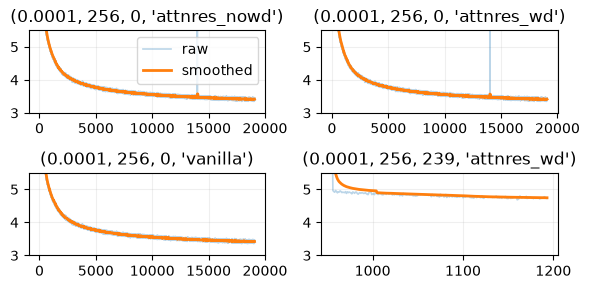

In [81]:
# testing smoothing

group_cols = HYPERPARAMETERS + ["method"]
raw_col = "lm loss"
smooth_col = f"{raw_col} smoothed"

keys = list(full_df.groupby(group_cols).groups.keys())[:4]

fig, axes = plt.subplots(2, 2, figsize=(6, 3), sharex=False, sharey=False)
axes = axes.flatten()

for ax, key in zip(axes, keys):
    gdf = full_df.set_index(group_cols).loc[key].sort_values("step")
    ax.plot(gdf["step"], gdf[raw_col], alpha=0.3, linewidth=1.2, label="raw")
    ax.plot(gdf["step"], gdf[smooth_col], linewidth=2.0, label="smoothed")
    ax.set_title(str(key))
    ax.set_ylim(3, 5.5)
    ax.grid(alpha=0.2)

axes[0].legend()
plt.tight_layout()
plt.show()

In [82]:
vanilla_df = full_df[full_df["method"] == "vanilla"].sort_values("step")
attnres_wd_df = full_df[full_df["method"] == "attnres_wd"].sort_values("step")
attnres_nowd_df = full_df[full_df["method"] == "attnres_nowd"].sort_values("step")

In [83]:
# vanilla_df = vanilla_df.loc[[ "branch=" not in v for v in vanilla_df.path.values]]
# attnres_wd_df = attnres_wd_df.loc[[ "branch=" not in v for v in attnres_wd_df.path.values]]
# attnres_nowd_df = attnres_nowd_df.loc[[ "branch=" not in v for v in attnres_nowd_df.path.values]]

In [84]:
print(f"vanilla_df shape: {vanilla_df.shape}")
print(f"attnres_wd_df shape: {attnres_wd_df.shape}")
print(f"attnres_nowd_df shape: {attnres_nowd_df.shape}")

vanilla_df shape: (411193, 43)
attnres_wd_df shape: (390202, 43)
attnres_nowd_df shape: (318042, 43)


In [85]:
Y_METRIC = "lm loss smoothed"
# Y_METRIC = "lm loss"

In [86]:
LOSS_RANGE = [np.inf, -np.inf]

for _df in [vanilla_df, attnres_wd_df, attnres_nowd_df]:
    result = (
        _df
        .sort_values("step")
        .groupby(HYPERPARAMETERS)[Y_METRIC]
        .last()
    )
    min_loss = result.min()
    max_loss = result.max()
    LOSS_RANGE[0] = min(LOSS_RANGE[0], min_loss)
    LOSS_RANGE[1] = max(LOSS_RANGE[1], max_loss)

print(f"LOSS_RANGE: {LOSS_RANGE}")

LOSS_RANGE: [np.float64(3.1163084650039674), np.float64(4.744842758178711)]


Index([0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03], dtype='float64', name='lr')
Index([0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03], dtype='float64', name='lr')
Index([0.0001, 0.0003, 0.001, 0.003], dtype='float64', name='lr')


<Figure size 640x480 with 0 Axes>

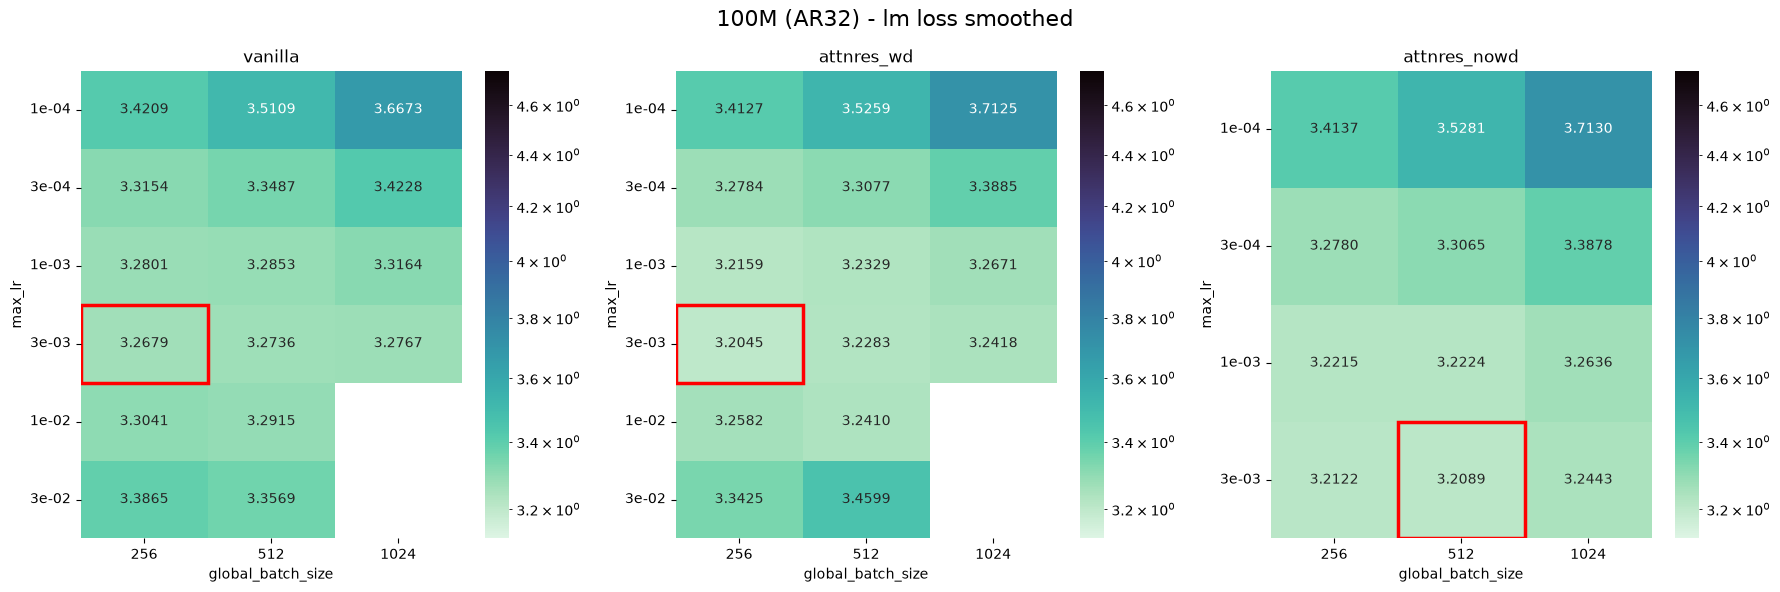

In [87]:
plt.clf()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  #, sharey=True)

for i, (_df, _method) in enumerate(zip(
    [vanilla_df, attnres_wd_df, attnres_nowd_df], 
    ["vanilla", "attnres_wd", "attnres_nowd"]
)):
    ax = axes[i]
    _df = _df.loc[_df["lr_wsd_decay_iters"] == 0].copy()
    result = (
        _df
        .sort_values("step")
        .groupby(["lr", "global_batch_size"])[Y_METRIC]
        .last()
    )
    print(result.unstack("global_batch_size").sort_index().index)
    ax = plot_heatmap(ax, result, title=_method, loss_range=LOSS_RANGE)

plt.suptitle(f"100M (AR32) - {Y_METRIC}", fontsize=16)
plt.tight_layout()

np.float64(-0.10309185504913332)

<Figure size 640x480 with 0 Axes>

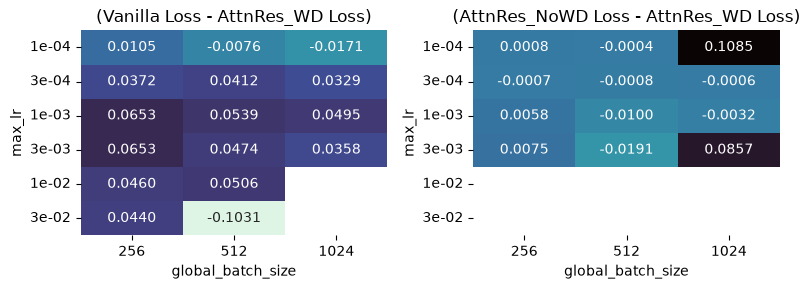

In [98]:
import matplotlib.colors as mcolors

plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3))  #, sharey=True)

_HYPERPARAMETERS = ["lr", "global_batch_size"]

result1 = (
    vanilla_df.sort_values("step").groupby(_HYPERPARAMETERS)[Y_METRIC].last()
    - attnres_wd_df.sort_values("step").groupby(_HYPERPARAMETERS)[Y_METRIC].last()
)
result2 = (
    attnres_nowd_df.sort_values("step").groupby(_HYPERPARAMETERS)[Y_METRIC].last()
    - attnres_wd_df.sort_values("step").groupby(_HYPERPARAMETERS)[Y_METRIC].last()
)

heat1 = result1.unstack("global_batch_size").sort_index()
heat2 = result2.unstack("global_batch_size").sort_index()

# shared scale across both panels
vmin = np.nanmin([np.nanmin(heat1.values), np.nanmin(heat2.to_numpy())])
vmax = np.nanmax([np.nanmax(heat1.to_numpy()), np.nanmax(heat2.to_numpy())])

# optional but great for difference plots: center colormap at 0
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

hm1 = sns.heatmap(
    heat1, annot=True, fmt=".4f", cmap="mako_r",
    norm=norm, cbar=False, ax=axes[0]
)
sns.heatmap(
    heat2, annot=True, fmt=".4f", cmap="mako_r",
    norm=norm, cbar=False, ax=axes[1]
)

axes[0].set_yticklabels([f"{v:.0e}" for v in heat1.index], rotation=0)
axes[1].set_yticklabels([f"{v:.0e}" for v in heat2.index], rotation=0)

axes[0].set_xlabel("global_batch_size")
axes[0].set_ylabel("max_lr")
axes[0].set_title("(Vanilla Loss - AttnRes_WD Loss)")

axes[1].set_xlabel("global_batch_size")
axes[1].set_ylabel("max_lr")
axes[1].set_title("(AttnRes_NoWD Loss - AttnRes_WD Loss)")

# reserve space at bottom for colorbar
# fig.subplots_adjust(bottom=0.2, wspace=0.25)

# # explicit colorbar axis: [left, bottom, width, height] in figure coords
# cax = fig.add_axes([0.20, 0.06, 0.60, 0.03])
# cbar = fig.colorbar(hm1.collections[0], cax=cax, orientation="horizontal", pad=-.55)
plt.tight_layout()

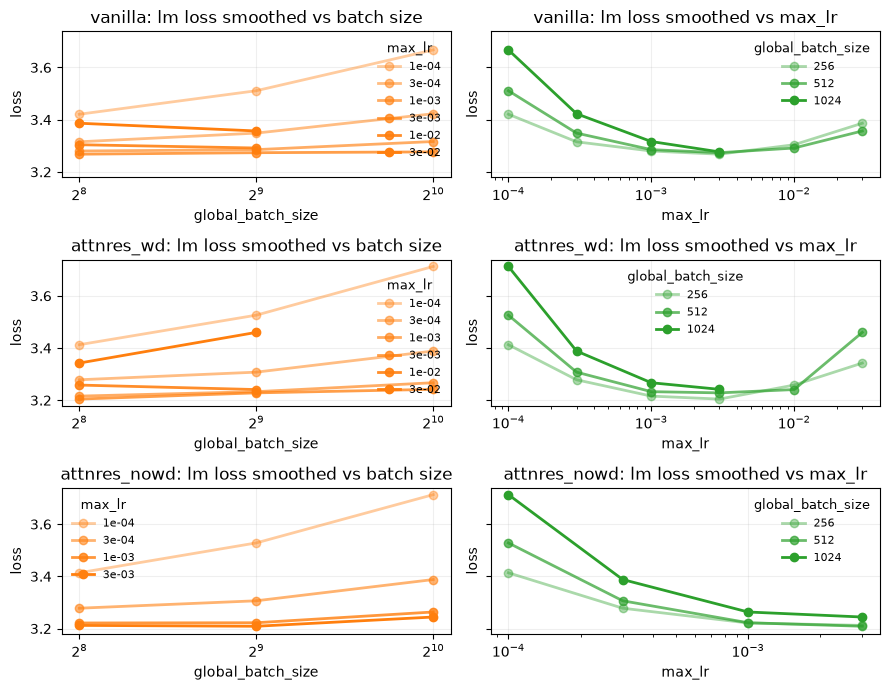

In [99]:
fig, ax = plt.subplots(3, 2, figsize=(9, 7), sharey=True)

for i, (_df, _method) in enumerate(zip(
    [vanilla_df, attnres_wd_df, attnres_nowd_df], 
    ["vanilla", "attnres_wd", "attnres_nowd"]
)):
    _df = _df.loc[_df["lr_wsd_decay_iters"] == 0].copy()
    result = (
        _df
        .sort_values("step")
        .groupby(["lr", "global_batch_size"])[Y_METRIC]
        .last()
    )
    plot_lr_lines(ax[i, 0], result, title=f"{_method}: {Y_METRIC} vs batch size")
    plot_bs_lines(ax[i, 1], result, title=f"{_method}: {Y_METRIC} vs max_lr")
plt.tight_layout()

In [100]:
# Y_METRIC = "lm loss validation smoothed"
Y_METRIC = "lm loss validation ppl"

In [101]:
LOSS_RANGE = [np.inf, -np.inf]

for _df in [vanilla_df, attnres_wd_df, attnres_nowd_df]:
    _df = _df.loc[_df["lr_wsd_decay_iters"] == 0].copy()
    result = (
        _df
        .sort_values("step")
        .groupby(["lr", "global_batch_size"])[Y_METRIC]
        .last()
    )
    min_loss = result.min()
    max_loss = result.max()
    LOSS_RANGE[0] = min(LOSS_RANGE[0], min_loss)
    LOSS_RANGE[1] = max(LOSS_RANGE[1], max_loss)

print(f"LOSS_RANGE: {LOSS_RANGE}")

LOSS_RANGE: [np.float64(24.273527145385742), np.float64(40.27725601196289)]


<Figure size 640x480 with 0 Axes>

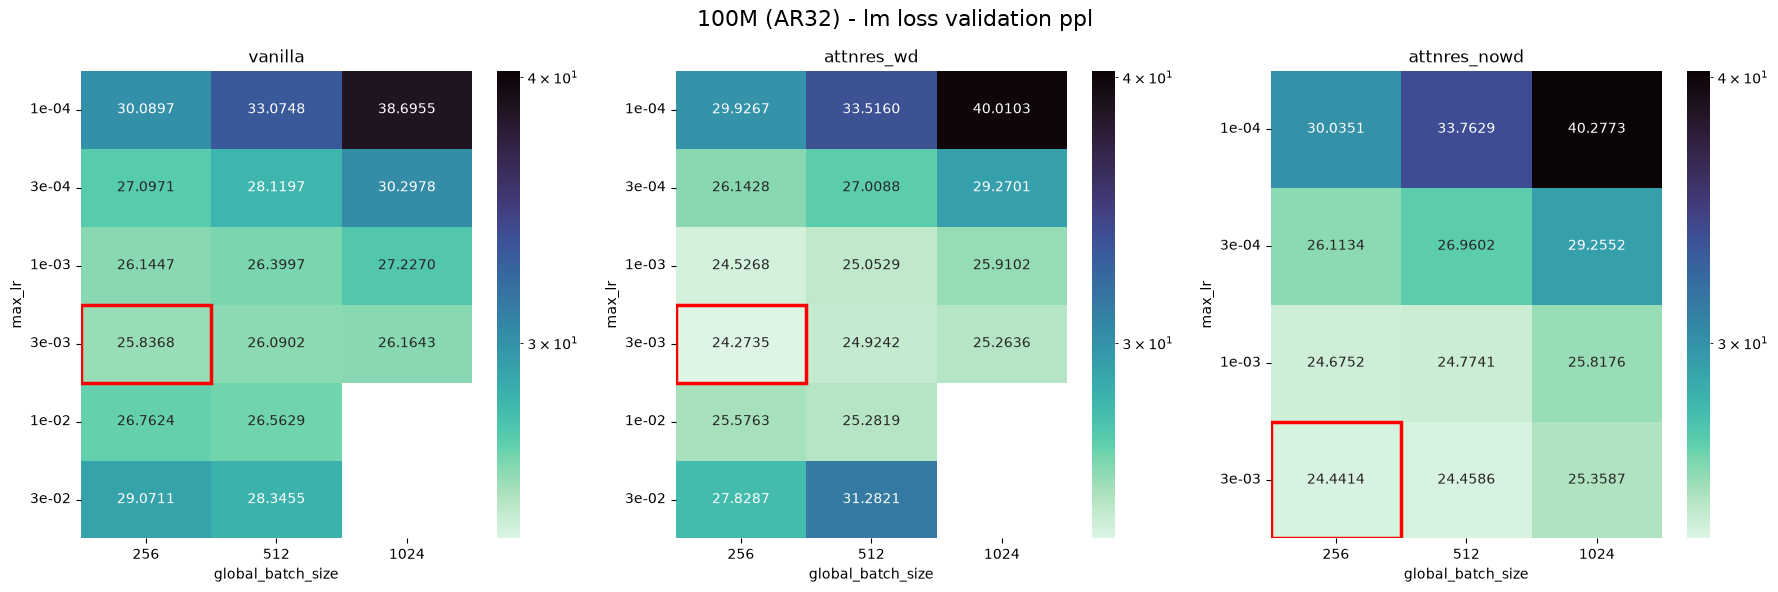

In [102]:
plt.clf()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  #, sharey=True)

for i, (_df, _method) in enumerate(zip(
    [vanilla_df, attnres_wd_df, attnres_nowd_df], 
    ["vanilla", "attnres_wd", "attnres_nowd"]
)):
    ax = axes[i]
    _df = _df.loc[_df["lr_wsd_decay_iters"] == 0].copy()
    result = (
        _df
        .sort_values("step")
        .groupby(["lr", "global_batch_size"])[Y_METRIC]
        .last()
    )
    ax = plot_heatmap(ax, result, title=_method, loss_range=LOSS_RANGE)
plt.suptitle(f"100M (AR32) - {Y_METRIC}", fontsize=16)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

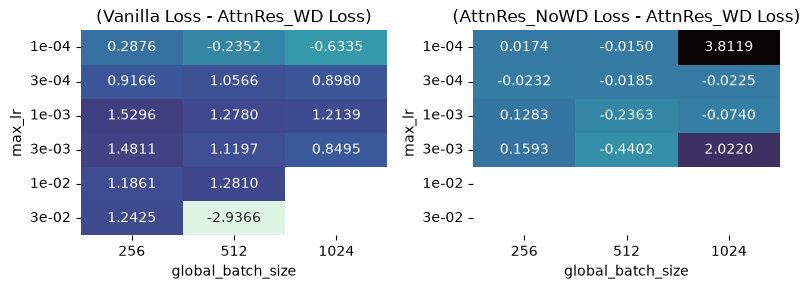

In [103]:
import matplotlib.colors as mcolors

plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3))  #, sharey=True)

_HYPERPARAMETERS = ["lr", "global_batch_size"]

result1 = (
    vanilla_df.sort_values("step").groupby(_HYPERPARAMETERS)[Y_METRIC].last()
    - attnres_wd_df.sort_values("step").groupby(_HYPERPARAMETERS)[Y_METRIC].last()
)
result2 = (
    attnres_nowd_df.sort_values("step").groupby(_HYPERPARAMETERS)[Y_METRIC].last()
    - attnres_wd_df.sort_values("step").groupby(_HYPERPARAMETERS)[Y_METRIC].last()
)

heat1 = result1.unstack("global_batch_size").sort_index()
heat2 = result2.unstack("global_batch_size").sort_index()

# shared scale across both panels
vmin = np.nanmin([np.nanmin(heat1.values), np.nanmin(heat2.to_numpy())])
vmax = np.nanmax([np.nanmax(heat1.to_numpy()), np.nanmax(heat2.to_numpy())])

# optional but great for difference plots: center colormap at 0
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

hm1 = sns.heatmap(
    heat1, annot=True, fmt=".4f", cmap="mako_r",
    norm=norm, cbar=False, ax=axes[0]
)
sns.heatmap(
    heat2, annot=True, fmt=".4f", cmap="mako_r",
    norm=norm, cbar=False, ax=axes[1]
)

axes[0].set_yticklabels([f"{v:.0e}" for v in heat1.index], rotation=0)
axes[1].set_yticklabels([f"{v:.0e}" for v in heat2.index], rotation=0)

axes[0].set_xlabel("global_batch_size")
axes[0].set_ylabel("max_lr")
axes[0].set_title("(Vanilla Loss - AttnRes_WD Loss)")

axes[1].set_xlabel("global_batch_size")
axes[1].set_ylabel("max_lr")
axes[1].set_title("(AttnRes_NoWD Loss - AttnRes_WD Loss)")

# reserve space at bottom for colorbar
# fig.subplots_adjust(bottom=0.2, wspace=0.25)

# # explicit colorbar axis: [left, bottom, width, height] in figure coords
# cax = fig.add_axes([0.20, 0.06, 0.60, 0.03])
# cbar = fig.colorbar(hm1.collections[0], cax=cax, orientation="horizontal", pad=-.55)
plt.tight_layout()

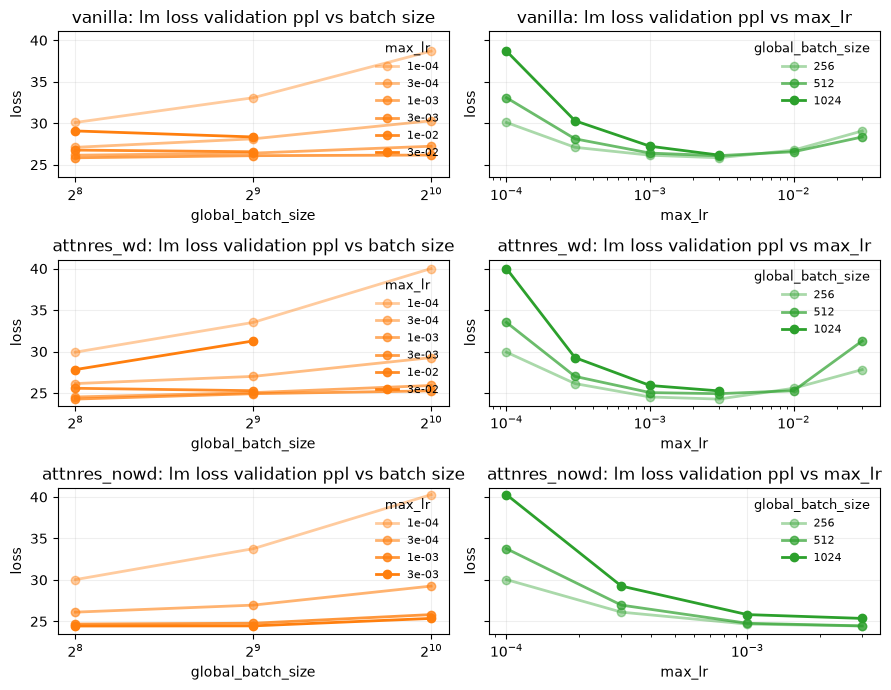

In [104]:
fig, ax = plt.subplots(3, 2, figsize=(9, 7), sharey=True)

for i, (_df, _method) in enumerate(zip(
    [vanilla_df, attnres_wd_df, attnres_nowd_df], 
    ["vanilla", "attnres_wd", "attnres_nowd"]
)):
    _df = _df.loc[_df["lr_wsd_decay_iters"] == 0].copy()
    result = (
        _df
        .sort_values("step")
        .groupby(["lr", "global_batch_size"])[Y_METRIC]
        .last()
    )
    plot_lr_lines(ax[i, 0], result, title=f"{_method}: {Y_METRIC} vs batch size")
    plot_bs_lines(ax[i, 1], result, title=f"{_method}: {Y_METRIC} vs max_lr")
plt.tight_layout()

### (Warmup-Stable-)DECAY runs for additional tokens on approx 117M model

In [106]:
# testing loss vs flops distribution

# plt.clf()
# for k, _idx in g.groups.items():
#     _df = full_df.loc[_idx]
#     N = _df["total_params"].iloc[-1]
#     D = _df["total_tokens"].iloc[-1]
#     L = _df["lm loss smoothed"].iloc[-1]
#     plt.scatter(_flops(N, D), L, color="black", alpha=0.3, s=10)
# plt.xlim(6e18, 1e19)
# plt.yscale("log")
# plt.ylim(3, 3.5)
# full_df.loc[g.groups[(0.0001, 256, 0, 'attnres_nowd')]]

In [107]:
g = full_df.groupby(HYPERPARAMETERS + ["method"])

29 --> 9 3
LOSS_RANGE: [np.float64(3.1816032552719116), np.float64(4.729355497360229)]


<Figure size 640x480 with 0 Axes>

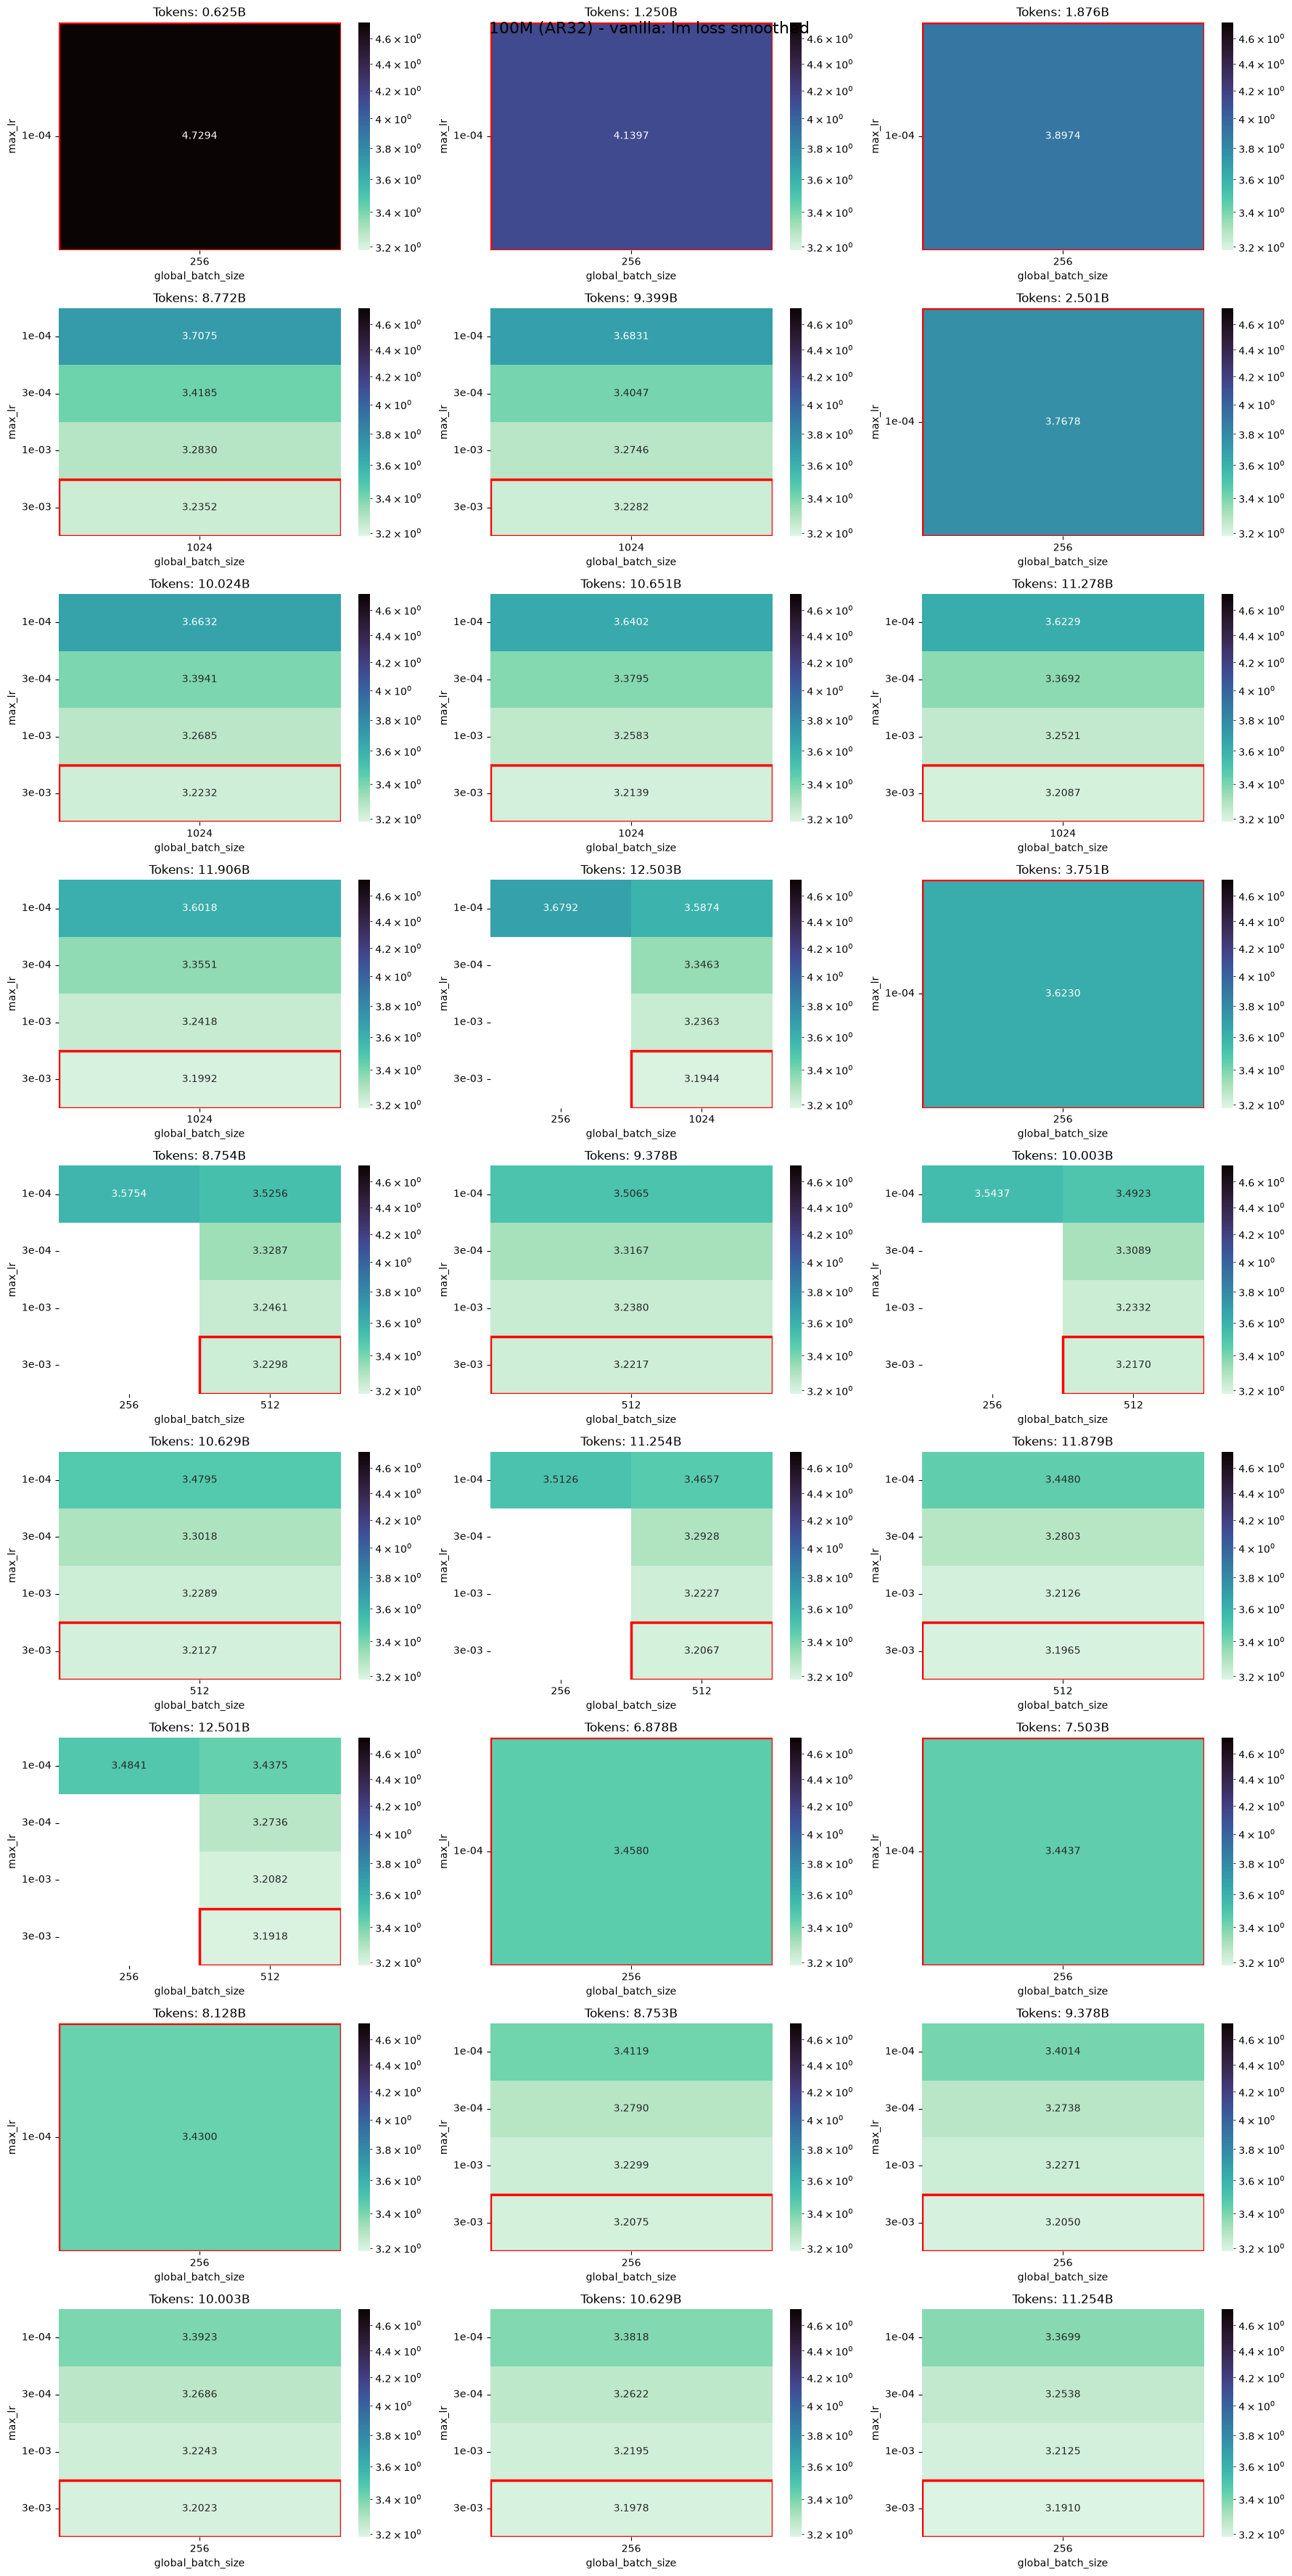

In [110]:
METHOD = "vanilla"
Y_METRIC = "lm loss smoothed"
MAX_COLS=3

total_plots = len(full_df.lr_wsd_decay_iters.unique()) - 1

ncols = min(total_plots, MAX_COLS)
nrows = total_plots // ncols
print(total_plots, "-->", nrows, ncols)

plt.clf()
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*4))  #, sharex=True, sharey=True)

_LOSS_RANGE = [np.inf, -np.inf]

_df = full_df.loc[full_df["method"] == METHOD].copy()
result = (
    _df
    .sort_values("step")
    .groupby(HYPERPARAMETERS)[Y_METRIC]
    .last()
)
min_loss = result.min()
max_loss = result.max()
_LOSS_RANGE[0] = min(_LOSS_RANGE[0], min_loss)
_LOSS_RANGE[1] = max(_LOSS_RANGE[1], max_loss)

print(f"LOSS_RANGE: {_LOSS_RANGE}")

branching = sorted(full_df.lr_wsd_decay_iters.unique())
branching.remove(0)  # skip the 0 branch since we already plotted it above
for i, (ax, branch) in enumerate(zip(axes.flat, branching)):
    # break
    # ax = axes[i]
    _df = full_df.loc[(full_df["lr_wsd_decay_iters"] == branch) & (full_df["method"] == METHOD)].copy()
    _tokens = _df.total_tokens.max()
    result = (
        _df
        .sort_values("step")
        .groupby(["lr", "global_batch_size"])[Y_METRIC]
        .last()
    )
    # skip if no data?
    # if result.empty:
    #     ax.set_title(f"Tokens: {_tokens/1e9:.3f}B (no data)")
    #     ax.axis("off")
    #     continue
    ax = plot_heatmap(ax, result, title=f"Tokens: {_tokens/1e9:.3f}B", loss_range=_LOSS_RANGE)
    # if i == 3:
    #     break

plt.suptitle(f"100M (AR32) - {METHOD}: {Y_METRIC}", fontsize=16)
plt.tight_layout()


In [111]:
full_df["cooldown_tokens"] = full_df["lr_wsd_decay_iters"] * full_df["global_batch_size"] * 2048
full_df["cooldown_frac"] = full_df["lr_wsd_decay_iters"] / full_df["train_iters"]

In [112]:
_df = full_df.loc[(full_df["method"] == "attnres_wd") & (full_df.lr_wsd_decay_iters != 0)].copy()

In [113]:
result = (
    _df
    .sort_values("step")
    .groupby(["lr", "global_batch_size"])["total_tokens"]
    .first()
)

In [ ]:
result

lr      global_batch_size
0.0001  256                   500695040
        512                  7003439104
        1024                 7019167744
0.0003  256                  7002914816
        512                  7003439104
        1024                 7019167744
0.0010  256                  7002914816
        512                  7003439104
        1024                 7019167744
0.0030  256                  7002914816
        512                  7003439104
        1024                 7019167744
Name: total_tokens, dtype: int64

In [ ]:
(
    _df
    .sort_values("step")
    .groupby(["lr", "global_batch_size"])["total_tokens"]
    .last()
) / 1e9

lr      global_batch_size
0.0001  256                  12.500599
        512                  12.501123
        1024                 12.503220
0.0003  256                  12.500599
        512                  12.501123
        1024                 12.503220
0.0010  256                  12.500599
        512                  12.501123
        1024                 12.503220
0.0030  256                  12.500599
        512                  12.501123
        1024                 12.503220
Name: total_tokens, dtype: float64

---